# Analysis Notebook for ACL Paper

This notebook computes statistics and generates tables/figures for the paper.

**Data sources:**
- `Data/narratives/*.csv` - Generated NLEs (9 strategies) - for **efficiency** analysis
- `Data/forsetzung_results/*/geval_*.csv` - G-Eval scores - for **quality** analysis

In [34]:
import pandas as pd
import numpy as np
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Paths
NARRATIVES_DIR = Path("../../Data/narratives")
EVAL_DIR = Path("../../Data/forsetzung_results/20250813_135743")

print(f"Narratives dir exists: {NARRATIVES_DIR.exists()}")
print(f"Evaluation dir exists: {EVAL_DIR.exists()}")

Narratives dir exists: True
Evaluation dir exists: True


In [35]:
# Load all narrative files (GENERATION data, not evaluation)
dfs = []
for csv_file in sorted(NARRATIVES_DIR.glob("*.csv")):
    strategy = csv_file.stem  # filename = strategy name
    temp_df = pd.read_csv(csv_file)
    temp_df['Strategy'] = strategy
    dfs.append(temp_df)
    print(f"Loaded {strategy}: {len(temp_df)} rows")

df_all = pd.concat(dfs, ignore_index=True)

# Separate main analysis from temperature sweep
df = df_all[df_all['Strategy'] != 'zero_shot_temp'].copy()
df_temp = df_all[df_all['Strategy'] == 'zero_shot_temp'].copy()

print(f"\n{'='*50}")
print(f"Total rows: {len(df_all):,}")
print(f"Main analysis (excl. temp sweep): {len(df):,}")
print(f"Temperature sweep: {len(df_temp):,}")

print(f"\nFactors in main analysis:")
for col in ['LLM', 'Model', 'XAI', 'Strategy']:
    print(f"  {col}: {df[col].nunique()} levels - {sorted(df[col].unique())}")

Loaded cot_few_shot: 60 rows
Loaded cot_zero_shot: 60 rows
Loaded few_shot: 90 rows
Loaded meta_prompting: 90 rows
Loaded reflexion: 90 rows
Loaded role_based: 90 rows
Loaded self_consistency: 90 rows
Loaded zero_shot: 90 rows
Loaded zero_shot_temp: 1890 rows

Total rows: 2,550
Main analysis (excl. temp sweep): 660
Temperature sweep: 1,890

Factors in main analysis:
  LLM: 3 levels - ['DEEPSEEK', 'GPT', 'L3_LOCAL']
  Model: 4 levels - ['MLP', 'RandomForest', 'SARIMAX', 'XGB']
  XAI: 3 levels - ['lime', 'none', 'shap']
  Strategy: 8 levels - ['cot_few_shot', 'cot_zero_shot', 'few_shot', 'meta_prompting', 'reflexion', 'role_based', 'self_consistency', 'zero_shot']


---

## 3. Quality Analysis (G-Eval Scores)

Now we load the **evaluation** data - G-Eval scores from both judges (GPT-4 and DeepSeek-R1).

**4 Evaluation Dimensions** (1-5 scale):
1. `accuracy` - Faithfulness to XAI outputs and factual correctness
2. `lay_user_relevancy` - Accessibility for non-experts
3. `expert_relevancy` - Technical depth for domain experts
4. `explanation_helpfulness` - Overall usefulness of the explanation

*Note: Prediction Closeness dimension was excluded from analysis as it conflates explanation quality with prediction accuracy.*

In [36]:
# Load G-Eval evaluation data from BOTH judges
geval_gpt4_raw = pd.read_csv(EVAL_DIR / "geval_gpt4.csv")
geval_deepseek_raw = pd.read_csv(EVAL_DIR / "geval_deepseek.csv")

# GPT-4 has token probability scores (g_eval_score)
# DeepSeek only has traditional scores (no logprobs API access)
# We'll create unified score columns for both

# Score column suffixes - 4 dimensions (Prediction Closeness excluded)
DIMS = ['accuracy', 'lay_user_relevancy', 'expert_relevancy', 
        'usefulness_explanation_helpfulness']

# Shorter names for display
DIM_NAMES = {
    'accuracy': 'Accuracy',
    'lay_user_relevancy': 'Lay Relevancy',
    'expert_relevancy': 'Expert Relevancy',
    'usefulness_explanation_helpfulness': 'Helpfulness'
}

# Create unified score columns
# GPT-4: use g_eval_score (token probability based)
# DeepSeek: use traditional_score (parsing-based)
geval_gpt4 = geval_gpt4_raw.copy()
geval_deepseek = geval_deepseek_raw.copy()

SCORE_COLS = []
for dim in DIMS:
    unified_col = f'score_{dim}'
    SCORE_COLS.append(unified_col)
    
    # GPT-4: prefer g_eval_score
    gpt4_col = f'eval_{dim}_g_eval_score'
    geval_gpt4[unified_col] = geval_gpt4_raw[gpt4_col]
    
    # DeepSeek: use traditional_score
    ds_col = f'eval_{dim}_traditional_score'
    geval_deepseek[unified_col] = geval_deepseek_raw[ds_col]

# Factor columns
FACTOR_COLS = ['LLM', 'Model', 'XAI', 'Strategy']

print(f"GPT-4 Judge: {len(geval_gpt4)} rows (using g_eval_score - token probabilities)")
print(f"DeepSeek Judge: {len(geval_deepseek)} rows (using traditional_score - no logprobs)")

print(f"\nEvaluation Dimensions (4):")
for col in SCORE_COLS:
    dim = col.replace('score_', '')
    print(f"  {DIM_NAMES[dim]}: GPT4 {geval_gpt4[col].min():.1f}-{geval_gpt4[col].max():.1f}, DS {geval_deepseek[col].min():.1f}-{geval_deepseek[col].max():.1f}")

print(f"\nFactors in evaluation data:")
for col in FACTOR_COLS:
    print(f"  {col}: {geval_gpt4[col].nunique()} levels - {sorted(geval_gpt4[col].unique())}")

GPT-4 Judge: 660 rows (using g_eval_score - token probabilities)
DeepSeek Judge: 660 rows (using traditional_score - no logprobs)

Evaluation Dimensions (4):
  Accuracy: GPT4 2.0-5.0, DS 1.0-5.0
  Lay Relevancy: GPT4 3.0-5.0, DS 3.0-5.0
  Expert Relevancy: GPT4 2.0-5.0, DS 2.0-5.0
  Helpfulness: GPT4 2.0-5.0, DS 2.0-5.0

Factors in evaluation data:
  LLM: 3 levels - ['DEEPSEEK', 'GPT', 'L3_LOCAL']
  Model: 4 levels - ['MLP', 'RandomForest', 'SARIMAX', 'XGB']
  XAI: 3 levels - ['lime', 'none', 'shap']
  Strategy: 8 levels - ['cot_few_shot', 'cot_zero_shot', 'few_shot', 'meta_prompting', 'reflexion', 'role_based', 'self_consistency', 'zero_shot']


In [37]:
# Check sample sizes per condition
print("Sample sizes by condition (GPT-4 judge):\n")

# Overall counts by each factor
for col in FACTOR_COLS:
    print(f"\n{col}:")
    counts = geval_gpt4.groupby(col).size().sort_values(ascending=False)
    for level, n in counts.items():
        print(f"  {level}: {n}")

# Cross-tabulation: LLM × Strategy (to see which combinations exist)
print("\n" + "="*60)
print("Cross-tabulation: LLM × Strategy")
print("="*60)
ct = pd.crosstab(geval_gpt4['LLM'], geval_gpt4['Strategy'])
display(ct)

# Check: do CoT strategies exclude DeepSeek?
print("\nNote: CoT strategies exclude DeepSeek-R1 (native reasoning model)")
cot_strategies = [s for s in geval_gpt4['Strategy'].unique() if 'cot' in s.lower()]
print(f"CoT strategies: {cot_strategies}")

Sample sizes by condition (GPT-4 judge):


LLM:
  GPT: 240
  L3_LOCAL: 240
  DEEPSEEK: 180

Model:
  MLP: 198
  RandomForest: 198
  XGB: 198
  SARIMAX: 66

XAI:
  none: 264
  lime: 198
  shap: 198

Strategy:
  meta_prompting: 90
  few_shot: 90
  role_based: 90
  reflexion: 90
  self_consistency: 90
  zero_shot: 90
  cot_few_shot: 60
  cot_zero_shot: 60

Cross-tabulation: LLM × Strategy


Strategy,cot_few_shot,cot_zero_shot,few_shot,meta_prompting,reflexion,role_based,self_consistency,zero_shot
LLM,,,,,,,,
DEEPSEEK,0,0,30,30,30,30,30,30
GPT,30,30,30,30,30,30,30,30
L3_LOCAL,30,30,30,30,30,30,30,30



Note: CoT strategies exclude DeepSeek-R1 (native reasoning model)
CoT strategies: ['cot_few_shot', 'cot_zero_shot']


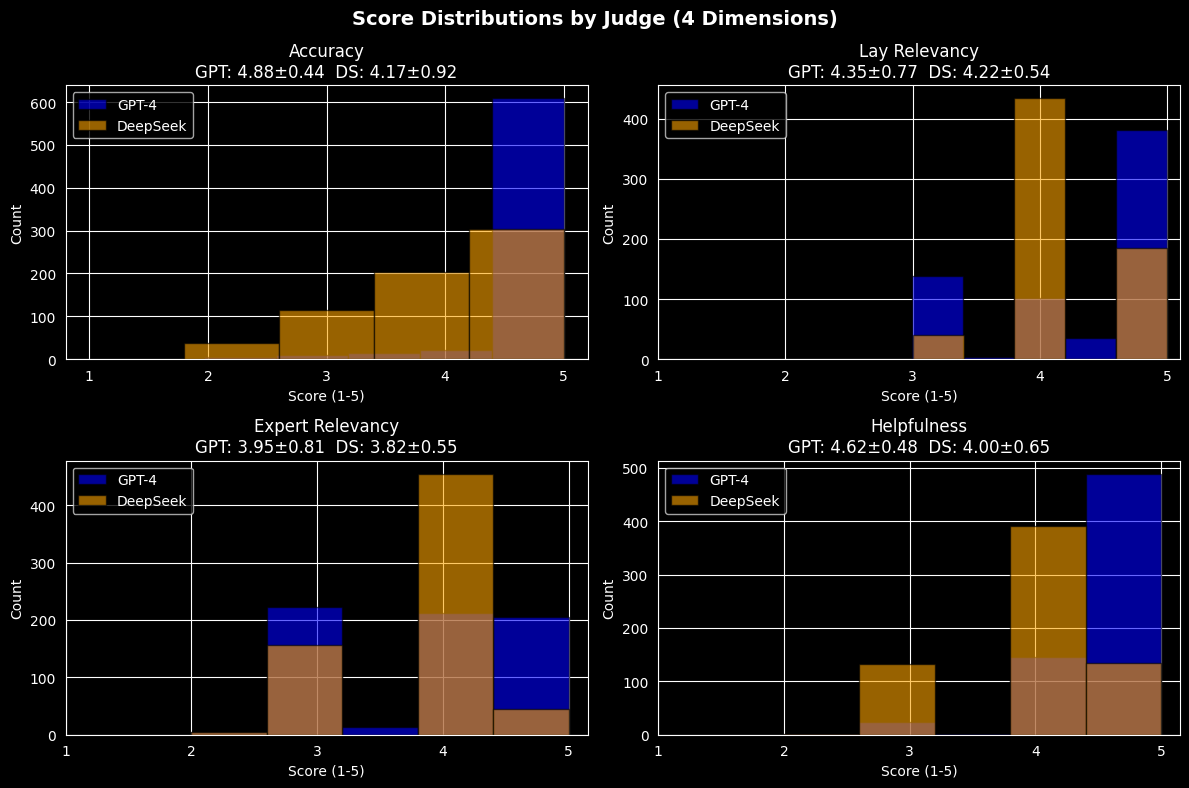


Summary Statistics (GPT-4 Judge):
----------------------------------------------------------------------


,dimension,count,mean,std,min,25%,50%,75%,max
score_accuracy,Accuracy,660.0,4.88,0.44,1.97,5.00,5.00,5.00,5.0
score_lay_user_relevancy,Lay Relevancy,660.0,4.35,0.77,2.99,4.00,4.83,4.98,5.0
score_expert_relevancy,Expert Relevancy,660.0,3.95,0.81,2.00,3.00,3.99,4.98,5.0
score_usefulness_explanation_helpfulness,Helpfulness,660.0,4.62,0.48,2.00,4.37,4.85,4.98,5.0


In [38]:
# Score distributions - Check for ceiling effects
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(SCORE_COLS):
    ax = axes[i]
    dim = col.replace('score_', '')
    dim_name = DIM_NAMES[dim]
    
    # Both judges on same plot
    ax.hist(geval_gpt4[col].dropna(), bins=5, alpha=0.6, label='GPT-4', color='blue', edgecolor='black')
    ax.hist(geval_deepseek[col].dropna(), bins=5, alpha=0.6, label='DeepSeek', color='orange', edgecolor='black')
    
    ax.set_xlabel('Score (1-5)')
    ax.set_ylabel('Count')
    ax.set_title(f'{dim_name}\nGPT: {geval_gpt4[col].mean():.2f}±{geval_gpt4[col].std():.2f}  DS: {geval_deepseek[col].mean():.2f}±{geval_deepseek[col].std():.2f}')
    ax.set_xticks([1, 2, 3, 4, 5])
    ax.legend()

plt.suptitle('Score Distributions by Judge (4 Dimensions)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Summary stats
print("\nSummary Statistics (GPT-4 Judge):")
print("-" * 70)
summary = geval_gpt4[SCORE_COLS].describe().T
summary['dimension'] = [DIM_NAMES[c.replace('score_', '')] for c in summary.index]
summary = summary[['dimension', 'count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']]
display(summary.round(2))

### 3.1 Merge Both Judges

We average scores from GPT-4 and DeepSeek judges for each explanation to mitigate potential self-preference bias (LLM judges may favor explanations from their own model family).

In [39]:
# Merge both judges by averaging their scores
# Both dataframes have the same rows in the same order (same 660 explanations)

df_eval = geval_gpt4[FACTOR_COLS].copy()  # Keep factor columns from one

# Average scores from both judges for each dimension
for col in SCORE_COLS:
    df_eval[col] = (geval_gpt4[col] + geval_deepseek[col]) / 2

# Verify
print("Merged evaluation dataset:")
print(f"  Rows: {len(df_eval)}")
print(f"  Factors: {FACTOR_COLS}")
print(f"  Score columns: {SCORE_COLS}")

print(f"\nScore ranges (averaged across both judges):")
for col in SCORE_COLS:
    dim = col.replace('score_', '')
    print(f"  {DIM_NAMES[dim]}: {df_eval[col].min():.2f} - {df_eval[col].max():.2f} (mean: {df_eval[col].mean():.2f})")

Merged evaluation dataset:
  Rows: 660
  Factors: ['LLM', 'Model', 'XAI', 'Strategy']
  Score columns: ['score_accuracy', 'score_lay_user_relevancy', 'score_expert_relevancy', 'score_usefulness_explanation_helpfulness']

Score ranges (averaged across both judges):
  Accuracy: 1.98 - 5.00 (mean: 4.52)
  Lay Relevancy: 3.00 - 5.00 (mean: 4.29)
  Expert Relevancy: 2.50 - 5.00 (mean: 3.88)
  Helpfulness: 2.49 - 5.00 (mean: 4.31)


In [40]:
# Statistical Helper Functions
# ============================

import subprocess, sys
for pkg in ['scipy', 'statsmodels', 'pingouin']:
    try:
        __import__(pkg)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

from scipy import stats
from scipy.stats import f_oneway, ttest_ind, kruskal
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.multitest import multipletests
import pingouin as pg

# --- Effect Size Functions ---

def cohens_d(g1, g2):
    """Cohen's d effect size for two groups."""
    n1, n2 = len(g1), len(g2)
    var1, var2 = g1.var(), g2.var()
    pooled_std = np.sqrt(((n1-1)*var1 + (n2-1)*var2) / (n1+n2-2))
    return (g1.mean() - g2.mean()) / pooled_std if pooled_std > 0 else 0

def omega_squared(f_stat, df_between, df_within, n_total):
    """
    Omega-squared (ω²) - less biased omnibus effect size for ANOVA.
    Interpretation: 0.01 = small, 0.06 = medium, 0.14 = large
    """
    ss_between = f_stat * df_between * (df_within / (n_total - df_between - 1))
    ms_within = df_within / (n_total - df_between - 1)
    omega_sq = (ss_between - df_between * ms_within) / (ss_between + (n_total - df_between) * ms_within + ms_within)
    return max(0, omega_sq)  # Can be negative for very small effects

def omega_sq_from_anova(*groups):
    """Compute omega-squared directly from group data."""
    k = len(groups)
    n_total = sum(len(g) for g in groups)
    df_between = k - 1
    df_within = n_total - k
    
    # Compute SS
    grand_mean = np.concatenate(groups).mean()
    ss_between = sum(len(g) * (g.mean() - grand_mean)**2 for g in groups)
    ss_within = sum(((g - g.mean())**2).sum() for g in groups)
    
    ms_within = ss_within / df_within
    omega_sq = (ss_between - df_between * ms_within) / (ss_between + ss_within + ms_within)
    return max(0, omega_sq)

def effect_label(d):
    """Interpret Cohen's d."""
    d = abs(d)
    if d < 0.2: return "negl."
    elif d < 0.5: return "small"
    elif d < 0.8: return "medium"
    else: return "large"

def omega_label(w2):
    """Interpret omega-squared."""
    if w2 < 0.01: return "negl."
    elif w2 < 0.06: return "small"
    elif w2 < 0.14: return "medium"
    else: return "large"

# --- FDR Correction ---

def fdr_correct(p_values, alpha=0.05):
    """
    Benjamini-Hochberg FDR correction.
    Returns: corrected p-values, reject array
    """
    reject, p_corrected, _, _ = multipletests(p_values, alpha=alpha, method='fdr_bh')
    return p_corrected, reject

# --- Welch ANOVA + Games-Howell ---

def welch_anova(data, dv, between):
    """
    Welch's ANOVA - robust to unequal variances.
    Returns F, p, omega-squared
    """
    result = pg.welch_anova(data=data, dv=dv, between=between)
    return result

def games_howell(data, dv, between):
    """
    Games-Howell post-hoc test - robust to unequal variances and sample sizes.
    """
    result = pg.pairwise_gameshowell(data=data, dv=dv, between=between)
    return result

print("Statistical helper functions loaded:")
print("  - cohens_d(g1, g2): Cohen's d effect size")
print("  - omega_sq_from_anova(*groups): ω² omnibus effect size")
print("  - effect_label(d), omega_label(w2): Interpret effect sizes")
print("  - fdr_correct(p_values): Benjamini-Hochberg FDR correction")
print("  - welch_anova(data, dv, between): Welch's ANOVA (robust)")
print("  - games_howell(data, dv, between): Games-Howell post-hoc (robust)")

Statistical helper functions loaded:
  - cohens_d(g1, g2): Cohen's d effect size
  - omega_sq_from_anova(*groups): ω² omnibus effect size
  - effect_label(d), omega_label(w2): Interpret effect sizes
  - fdr_correct(p_values): Benjamini-Hochberg FDR correction
  - welch_anova(data, dv, between): Welch's ANOVA (robust)
  - games_howell(data, dv, between): Games-Howell post-hoc (robust)


---

## 7. RQ3: Effect of ML Model on NLE Quality

**Research Question**: Does the underlying ML model quality affect NLE quality? Do classical models (SARIMAX) perform differently than ML models?

**Design**: 4 models × 660 explanations (unbalanced: SARIMAX N=66 only XAI='none'; ML models N=198 each)

**Models** (ordered by predictive performance R²):
1. XGBoost (R²=0.69) - best ML model
2. SARIMAX (R²=0.55) - classical time series model
3. Random Forest (R²=0.37)
4. MLP (R²=0.21)

---

### Statistical Analysis Pipeline (Standardized)

Following our standardized methodology (see Appendix E.1):

1. **One-way ANOVA** with ω² effect sizes
2. **Pairwise t-tests** with Cohen's d and FDR correction
3. **Welch ANOVA** (robustness check)
4. **Games-Howell post-hoc** (robust to unequal variances)
5. **Factorial Model** (controlling for LLM, XAI, Strategy)
6. **Interaction Tests**: Model × LLM, Model × XAI, Model × Strategy
7. **Simple Effects** (for significant interactions)

---

### Key Results

**Main Finding**: XGBoost (highest R²) produces best NLEs on most dimensions. Model choice matters more for Lay Relevancy.

| Dimension | F | p | ω² | Effect |
|-----------|---|---|-----|--------|
| Accuracy | 0.71 | .547 | .000 | negl. |
| **Lay Relevancy** | **26.70** | **<.001** | **.105** | **medium** |
| Expert Relevancy | 4.61 | .003 | .016 | small |
| **Helpfulness** | **7.79** | **<.001** | **.030** | **small** |

**SARIMAX vs ML (pooled)**: SARIMAX underperforms ML models on Lay Relevancy (d=-0.51) and Helpfulness (d=-0.42).

---

### Summary for Paper

> Model choice significantly affects NLE quality (ANOVA F=4.6–26.7, p<0.01 for 3/4 dimensions). **XGBoost** (R²=0.69) achieves the highest NLE quality, particularly on Lay Relevancy. The classical **SARIMAX** model significantly underperforms ML models on Lay Relevancy (d=-0.51, p<0.001) and Helpfulness (d=-0.42, p=0.001), despite its inherent interpretability. This suggests that explanation quality benefits from underlying model accuracy. Accuracy scores show no model effect, suggesting LLMs can generate factually correct explanations regardless of model quality.

In [41]:
# RQ3: Model Effect - Descriptive Statistics
# ===========================================

df_model = df_eval.copy()

# Model display names with R² scores (correct values from Table 1)
MODEL_NAMES = {
    'XGB': 'XGBoost (R²=0.69)',
    'SARIMAX': 'SARIMAX (R²=0.55)',
    'RandomForest': 'RF (R²=0.37)',
    'MLP': 'MLP (R²=0.21)'
}

# Correct R² values from Table 1 in paper
MODEL_R2 = {'XGB': 0.69, 'SARIMAX': 0.55, 'RandomForest': 0.37, 'MLP': 0.21}

print(f"Full dataset: {len(df_model)} rows")
print(f"Model groups: {df_model.groupby('Model').size().to_dict()}")
print(f"Note: SARIMAX has N=66 (only XAI='none'), ML models have N=198 each")

# Compute mean ± std for each Model × dimension
model_stats = df_model.groupby('Model')[SCORE_COLS].agg(['mean', 'std', 'count'])
model_stats.columns = ['_'.join(col) for col in model_stats.columns]

print("\n" + "="*80)
print("RQ3: Model Effect on NLE Quality (Averaged across both judges)")
print("="*80)

# Build results table sorted by R²
results = []
for model in ['XGB', 'SARIMAX', 'RandomForest', 'MLP']:
    row = {'Model': MODEL_NAMES.get(model, model)}
    row['N'] = int(df_model[df_model['Model'] == model].shape[0])
    row['R²'] = MODEL_R2[model]
    for col in SCORE_COLS:
        dim = col.replace('score_', '')
        mean = model_stats.loc[model, f'{col}_mean']
        std = model_stats.loc[model, f'{col}_std']
        row[DIM_NAMES[dim]] = f"{mean:.2f} ± {std:.2f}"
    results.append(row)

results_df = pd.DataFrame(results)
display(results_df)

# Means only - sorted by R²
print("\nMeans only (sorted by model R²):")
means_df = df_model.groupby('Model')[SCORE_COLS].mean()
means_df.columns = [DIM_NAMES[c.replace('score_', '')] for c in means_df.columns]
means_df['Overall'] = means_df.mean(axis=1)
means_df = means_df.loc[['XGB', 'SARIMAX', 'RandomForest', 'MLP']].round(3)
means_df.index = [MODEL_NAMES.get(x, x) for x in means_df.index]
display(means_df)

Full dataset: 660 rows
Model groups: {'MLP': 198, 'RandomForest': 198, 'SARIMAX': 66, 'XGB': 198}
Note: SARIMAX has N=66 (only XAI='none'), ML models have N=198 each

RQ3: Model Effect on NLE Quality (Averaged across both judges)


,Model,N,R²,Accuracy,Lay Relevancy,Expert Relevancy,Helpfulness
0,XGBoost (R²=0.69),198,0.69,4.56 ± 0.55,4.53 ± 0.48,4.00 ± 0.58,4.43 ± 0.48
1,SARIMAX (R²=0.55),66,0.55,4.47 ± 0.66,4.04 ± 0.52,3.76 ± 0.69,4.12 ± 0.44
2,RF (R²=0.37),198,0.37,4.53 ± 0.55,4.29 ± 0.55,3.82 ± 0.53,4.27 ± 0.52
3,MLP (R²=0.21),198,0.21,4.50 ± 0.61,4.12 ± 0.52,3.86 ± 0.61,4.29 ± 0.50



Means only (sorted by model R²):


,Accuracy,Lay Relevancy,Expert Relevancy,Helpfulness,Overall
XGBoost (R²=0.69),4.564,4.535,4.003,4.432,4.384
SARIMAX (R²=0.55),4.465,4.037,3.756,4.121,4.094
RF (R²=0.37),4.534,4.285,3.821,4.271,4.228
MLP (R²=0.21),4.496,4.123,3.863,4.291,4.193


In [42]:
# RQ3: Statistical Analysis
# =========================

# Get model groups
models = ['XGB', 'RandomForest', 'MLP', 'SARIMAX']
model_groups = {m: df_model[df_model['Model'] == m] for m in models}

# =====================================================
# FOR MAIN PAPER: ANOVA with ω² + FDR
# =====================================================
print("="*80)
print("FOR MAIN PAPER: RQ3 Summary (Model Effect)")
print("="*80)

# ANOVA with omega-squared
print("\n### ANOVA (overall Model effect) with ω² ###")
print(f"{'Dimension':<18} {'F':>8} {'p':>10} {'ω²':>8} {'Effect':>8} {'Sig'}")
print("-"*60)

anova_results_model = []
for col in SCORE_COLS:
    dim = DIM_NAMES[col.replace('score_', '')]
    groups = [model_groups[m][col].values for m in models]
    f_stat, p_val = f_oneway(*[model_groups[m][col] for m in models])
    w2 = omega_sq_from_anova(*groups)
    sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else ""
    anova_results_model.append({'dim': dim, 'F': f_stat, 'p': p_val, 'w2': w2})
    print(f"{dim:<18} {f_stat:>8.2f} {p_val:>10.4f} {w2:>8.3f} {omega_label(w2):>8} {sig}")

# FDR correction
p_values = [r['p'] for r in anova_results_model]
p_fdr, reject_fdr = fdr_correct(p_values)
print(f"\nFDR-corrected p-values:")
for i, r in enumerate(anova_results_model):
    sig_fdr = "*" if reject_fdr[i] else ""
    print(f"  {r['dim']:<18} p_raw={r['p']:.4f} → p_FDR={p_fdr[i]:.4f} {sig_fdr}")

# SARIMAX vs ML models comparison
print("\n### SARIMAX vs ML Models (pooled XGB+RF+MLP) ###")

sarimax = model_groups['SARIMAX']
ml_pooled = df_model[df_model['Model'].isin(['XGB', 'RandomForest', 'MLP'])]

print(f"{'Dimension':<18} {'SARIMAX':>8} {'ML':>8} {'Δ':>8} {'d':>8} {'p':>10} {'p_FDR':>10}")
print("-"*75)

sarimax_p = []
sarimax_info = []
for col in SCORE_COLS:
    dim = DIM_NAMES[col.replace('score_', '')]
    sar_mean = sarimax[col].mean()
    ml_mean = ml_pooled[col].mean()
    diff = sar_mean - ml_mean
    d = cohens_d(sarimax[col], ml_pooled[col])
    t, p = ttest_ind(sarimax[col], ml_pooled[col])
    sarimax_p.append(p)
    sarimax_info.append((dim, sar_mean, ml_mean, diff, d, p))

p_fdr_sar, reject_sar = fdr_correct(sarimax_p)
for i, (dim, sar_mean, ml_mean, diff, d, p_raw) in enumerate(sarimax_info):
    sig = "*" if reject_sar[i] else ""
    print(f"{dim:<18} {sar_mean:>8.2f} {ml_mean:>8.2f} {diff:>+8.2f} {d:>+8.2f} {p_raw:>9.3f} {p_fdr_sar[i]:>9.3f}{sig}")

# Correlation
print("\n### Correlation: Model R² vs NLE Quality ###")
model_level = []
for m in models:
    model_level.append({'Model': m, 'R2': MODEL_R2[m], 
                        'Overall': df_model[df_model['Model'] == m][SCORE_COLS].mean().mean()})
model_df_corr = pd.DataFrame(model_level)
rho, _ = stats.spearmanr(model_df_corr['R2'], model_df_corr['Overall'])
print(f"Spearman ρ (R² vs Overall NLE): {rho:.3f} (n=4, descriptive only)")

# =====================================================
# FOR APPENDIX: Tukey HSD
# =====================================================
print("\n" + "="*80)
print("FOR APPENDIX: Tukey HSD (significant pairs)")
print("="*80)

for col in SCORE_COLS:
    dim = DIM_NAMES[col.replace('score_', '')]
    tukey = pairwise_tukeyhsd(df_model[col], df_model['Model'], alpha=0.05)
    sig_count = sum(tukey.reject)
    print(f"\n{dim}: {sig_count} significant pairs")

FOR MAIN PAPER: RQ3 Summary (Model Effect)

### ANOVA (overall Model effect) with ω² ###
Dimension                 F          p       ω²   Effect Sig
------------------------------------------------------------
Accuracy               0.71     0.5466    0.000    negl. 
Lay Relevancy         26.70     0.0000    0.105   medium ***
Expert Relevancy       4.61     0.0033    0.016    small **
Helpfulness            7.79     0.0000    0.030    small ***

FDR-corrected p-values:
  Accuracy           p_raw=0.5466 → p_FDR=0.5466 
  Lay Relevancy      p_raw=0.0000 → p_FDR=0.0000 *
  Expert Relevancy   p_raw=0.0033 → p_FDR=0.0045 *
  Helpfulness        p_raw=0.0000 → p_FDR=0.0001 *

### SARIMAX vs ML Models (pooled XGB+RF+MLP) ###
Dimension           SARIMAX       ML        Δ        d          p      p_FDR
---------------------------------------------------------------------------
Accuracy               4.47     4.53    -0.07    -0.11     0.378     0.378
Lay Relevancy          4.04     4.31    -0.

In [ ]:
# RQ3: Pairwise Comparisons with Cohen's d (Like RQ1/RQ2)
# =========================================================
# ALL pairwise comparisons between models with effect sizes

print("="*80)
print("FOR APPENDIX: Pairwise Comparisons with Effect Sizes (FDR-corrected)")
print("="*80)

# Model short names for display
MODEL_SHORT = {'XGB': 'XGB', 'RandomForest': 'RF', 'MLP': 'MLP', 'SARIMAX': 'SARIMAX'}

# All pairwise comparisons (6 pairs for 4 models)
model_pairs = [
    ('XGB', 'RandomForest'),
    ('XGB', 'MLP'),
    ('XGB', 'SARIMAX'),
    ('RandomForest', 'MLP'),
    ('RandomForest', 'SARIMAX'),
    ('MLP', 'SARIMAX')
]

for col in SCORE_COLS:
    dim = DIM_NAMES[col.replace('score_', '')]
    print(f"\n{dim}:")
    
    pairwise_p = []
    pairwise_info = []
    
    for m1, m2 in model_pairs:
        g1 = model_groups[m1][col]
        g2 = model_groups[m2][col]
        diff = g1.mean() - g2.mean()
        d = cohens_d(g1, g2)
        t, p = ttest_ind(g1, g2)
        pairwise_p.append(p)
        pairwise_info.append((MODEL_SHORT[m1], MODEL_SHORT[m2], diff, d, p))
    
    # FDR correction within dimension
    p_fdr_pair, reject_pair = fdr_correct(pairwise_p)
    
    for i, (name1, name2, diff, d, p_raw) in enumerate(pairwise_info):
        sig = "*" if reject_pair[i] else ""
        print(f"  {name1:8} vs {name2:8}: Δ={diff:+.3f}, d={d:+.3f} ({effect_label(d):6}), p={p_raw:.3f}, p_FDR={p_fdr_pair[i]:.3f}{sig}")

In [44]:
# RQ3: Robustness Check - Welch ANOVA
# ====================================

print("="*80)
print("FOR APPENDIX: Robustness Check - Welch ANOVA")
print("="*80)

print("\n### Welch ANOVA (robust to heterogeneous variances) ###")
print(f"{'Dimension':<18} {'F':>8} {'p':>10} {'Sig'}")
print("-"*45)

for col in SCORE_COLS:
    dim = DIM_NAMES[col.replace('score_', '')]
    welch_result = welch_anova(data=df_model, dv=col, between='Model')
    f_stat = welch_result['F'].values[0]
    p_val = welch_result['p-unc'].values[0]
    sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else ""
    print(f"{dim:<18} {f_stat:>8.2f} {p_val:>10.4f} {sig}")

FOR APPENDIX: Robustness Check - Welch ANOVA

### Welch ANOVA (robust to heterogeneous variances) ###
Dimension                 F          p Sig
---------------------------------------------
Accuracy               0.66     0.5758 
Lay Relevancy         28.89     0.0000 ***
Expert Relevancy       4.54     0.0041 **
Helpfulness            8.72     0.0000 ***


In [45]:
# RQ3: Generate LaTeX Table
# ==========================

def generate_model_latex_table(df, score_cols, dim_names, model_names, model_r2):
    """Generate LaTeX table for Model comparison with Overall column, sorted by Overall."""
    
    lines = []
    lines.append(r"\begin{table}[t]")
    lines.append(r"  \centering")
    lines.append(r"  \small")
    lines.append(r"  \caption{G-Eval scores by ML model, sorted by average. XGBoost (highest R$^2$) yields best NLEs. Bold = best per column.}")
    lines.append(r"  \label{tab:model_results}")
    lines.append(r"  \begin{tabular}{@{}lccccc@{}}")
    lines.append(r"    \toprule")
    
    # Header with Avg. column (4 dimensions + avg)
    dim_short = ['Acc.', 'Lay', 'Exp.', 'Help.', 'Avg.']
    lines.append(r"    \textbf{Model} & " + " & ".join([f"\\textbf{{{d}}}" for d in dim_short]) + r" \\")
    lines.append(r"    \midrule")
    
    # Compute stats
    means_only = df.groupby('Model')[score_cols].mean()
    
    # Add Overall column
    means_only['Overall'] = means_only.mean(axis=1)
    
    # Find best (highest) per column
    best_per_dim = means_only.idxmax()
    
    # Sort by Overall descending
    means_only = means_only.sort_values('Overall', ascending=False)
    
    # Rows
    for model in means_only.index:
        row_parts = [model_names.get(model, model)]
        for col in score_cols:
            mean = means_only.loc[model, col]
            if best_per_dim[col] == model:
                row_parts.append(f"\\textbf{{{mean:.2f}}}")
            else:
                row_parts.append(f"{mean:.2f}")
        # Add Overall
        overall = means_only.loc[model, 'Overall']
        if best_per_dim['Overall'] == model:
            row_parts.append(f"\\textbf{{{overall:.2f}}}")
        else:
            row_parts.append(f"{overall:.2f}")
        lines.append(f"    {' & '.join(row_parts)} \\\\")
    
    lines.append(r"    \bottomrule")
    lines.append(r"  \end{tabular}")
    lines.append(r"\end{table}")
    
    return "\n".join(lines)

# Generate LaTeX table (4 dimensions)
latex_model_table = generate_model_latex_table(df_model, SCORE_COLS, DIM_NAMES, MODEL_NAMES, MODEL_R2)
print("LaTeX Table for RQ3 (Model Effect) - 4 Dimensions:")
print("="*80)
print(latex_model_table)

LaTeX Table for RQ3 (Model Effect) - 4 Dimensions:
\begin{table}[t]
  \centering
  \small
  \caption{G-Eval scores by ML model, sorted by average. XGBoost (highest R$^2$) yields best NLEs. Bold = best per column.}
  \label{tab:model_results}
  \begin{tabular}{@{}lccccc@{}}
    \toprule
    \textbf{Model} & \textbf{Acc.} & \textbf{Lay} & \textbf{Exp.} & \textbf{Help.} & \textbf{Avg.} \\
    \midrule
    XGBoost (R²=0.69) & \textbf{4.56} & \textbf{4.53} & \textbf{4.00} & \textbf{4.43} & \textbf{4.38} \\
    RF (R²=0.37) & 4.53 & 4.29 & 3.82 & 4.27 & 4.23 \\
    MLP (R²=0.21) & 4.50 & 4.12 & 3.86 & 4.29 & 4.19 \\
    SARIMAX (R²=0.55) & 4.47 & 4.04 & 3.76 & 4.12 & 4.09 \\
    \bottomrule
  \end{tabular}
\end{table}


In [46]:
# RQ3: Games-Howell Post-hoc (Robust to unequal variances)
# =========================================================
# Excluding SARIMAX - ML models only (N=594)

print("="*80)
print("FOR APPENDIX: Games-Howell Post-hoc (ML models only, N=594)")
print("="*80)

# Filter to ML models only
df_ml = df_model[df_model['Model'].isin(['XGB', 'RandomForest', 'MLP'])].copy()
print(f"ML models only: N={len(df_ml)}")

for col in SCORE_COLS:
    dim = DIM_NAMES[col.replace('score_', '')]
    gh = games_howell(data=df_ml, dv=col, between='Model')
    sig_pairs = gh[gh['pval'] < 0.05]
    print(f"\n{dim}: {len(sig_pairs)} significant pairs")
    if len(sig_pairs) > 0:
        for _, row in sig_pairs.iterrows():
            d = row['hedges']  # Games-Howell uses Hedges' g
            print(f"  {row['A']} vs {row['B']}: Δ={row['diff']:.2f}, g={d:.2f}, p={row['pval']:.4f}")

FOR APPENDIX: Games-Howell Post-hoc (ML models only, N=594)
ML models only: N=594

Accuracy: 0 significant pairs

Lay Relevancy: 3 significant pairs
  MLP vs RandomForest: Δ=-0.16, g=-0.30, p=0.0083
  MLP vs XGB: Δ=-0.41, g=-0.82, p=0.0000
  RandomForest vs XGB: Δ=-0.25, g=-0.48, p=0.0000

Expert Relevancy: 1 significant pairs
  RandomForest vs XGB: Δ=-0.18, g=-0.33, p=0.0034

Helpfulness: 2 significant pairs
  MLP vs XGB: Δ=-0.14, g=-0.29, p=0.0118
  RandomForest vs XGB: Δ=-0.16, g=-0.32, p=0.0043


In [47]:
# RQ3: Factorial Model (Controlling for LLM, XAI, Strategy)
# ==========================================================
# ML models only (N=594)

print("="*80)
print("FOR APPENDIX: Factorial Model - Model effect controlling for confounds")
print("="*80)

import statsmodels.api as sm
from statsmodels.formula.api import ols

print("\n### Model effect controlling for LLM, XAI, Strategy (Type II SS) ###")
print(f"{'Dimension':<18} {'F':>8} {'p':>10} {'η²p':>8} {'Sig'}")
print("-"*50)

factorial_results = []
for col in SCORE_COLS:
    dim = DIM_NAMES[col.replace('score_', '')]
    # Fit model with all factors
    model = ols(f'{col} ~ C(Model) + C(LLM) + C(XAI) + C(Strategy)', data=df_ml).fit()
    anova_table = sm.stats.anova_lm(model, typ=2)
    
    # Extract Model effect
    f_stat = anova_table.loc['C(Model)', 'F']
    p_val = anova_table.loc['C(Model)', 'PR(>F)']
    ss_model = anova_table.loc['C(Model)', 'sum_sq']
    ss_resid = anova_table.loc['Residual', 'sum_sq']
    eta_sq_partial = ss_model / (ss_model + ss_resid)
    
    sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else ""
    factorial_results.append({'dim': dim, 'F': f_stat, 'p': p_val, 'eta2p': eta_sq_partial})
    print(f"{dim:<18} {f_stat:>8.2f} {p_val:>10.4f} {eta_sq_partial:>8.3f} {sig}")

# FDR correction
p_vals = [r['p'] for r in factorial_results]
p_fdr, reject = fdr_correct(p_vals)
print(f"\nFDR-corrected:")
for i, r in enumerate(factorial_results):
    sig = "*" if reject[i] else ""
    print(f"  {r['dim']:<18} p_FDR={p_fdr[i]:.4f} {sig}")

FOR APPENDIX: Factorial Model - Model effect controlling for confounds

### Model effect controlling for LLM, XAI, Strategy (Type II SS) ###
Dimension                 F          p      η²p Sig
--------------------------------------------------
Accuracy               1.02     0.3604    0.004 
Lay Relevancy         51.94     0.0000    0.152 ***
Expert Relevancy      11.65     0.0000    0.039 ***
Helpfulness           11.89     0.0000    0.039 ***

FDR-corrected:
  Accuracy           p_FDR=0.3604 
  Lay Relevancy      p_FDR=0.0000 *
  Expert Relevancy   p_FDR=0.0000 *
  Helpfulness        p_FDR=0.0000 *


In [48]:
# RQ3: Interaction Tests (Model × LLM, Model × XAI, Model × Strategy)
# ====================================================================
# Per standardized template: test ALL two-way interactions

print("="*80)
print("FOR APPENDIX: Interaction Tests")
print("="*80)

import statsmodels.api as sm

# Model × LLM interaction
print("\n### Model × LLM Interaction ###")
print(f"{'Dimension':<18} {'F':>8} {'p':>10} {'η²p':>8} {'Sig'}")
print("-"*50)

interaction_llm = []
for col in SCORE_COLS:
    dim = DIM_NAMES[col.replace('score_', '')]
    model = ols(f'{col} ~ C(Model) * C(LLM)', data=df_ml).fit()
    anova_table = sm.stats.anova_lm(model, typ=2)
    
    f_stat = anova_table.loc['C(Model):C(LLM)', 'F']
    p_val = anova_table.loc['C(Model):C(LLM)', 'PR(>F)']
    ss_int = anova_table.loc['C(Model):C(LLM)', 'sum_sq']
    ss_resid = anova_table.loc['Residual', 'sum_sq']
    eta_sq_partial = ss_int / (ss_int + ss_resid)
    
    sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else ""
    interaction_llm.append({'dim': dim, 'F': f_stat, 'p': p_val, 'eta2p': eta_sq_partial, 'sig': p_val < 0.05})
    print(f"{dim:<18} {f_stat:>8.2f} {p_val:>10.4f} {eta_sq_partial:>8.3f} {sig}")

# Model × XAI interaction
print("\n### Model × XAI Interaction ###")
print(f"{'Dimension':<18} {'F':>8} {'p':>10} {'η²p':>8} {'Sig'}")
print("-"*50)

interaction_xai = []
for col in SCORE_COLS:
    dim = DIM_NAMES[col.replace('score_', '')]
    model = ols(f'{col} ~ C(Model) * C(XAI)', data=df_ml).fit()
    anova_table = sm.stats.anova_lm(model, typ=2)
    
    f_stat = anova_table.loc['C(Model):C(XAI)', 'F']
    p_val = anova_table.loc['C(Model):C(XAI)', 'PR(>F)']
    ss_int = anova_table.loc['C(Model):C(XAI)', 'sum_sq']
    ss_resid = anova_table.loc['Residual', 'sum_sq']
    eta_sq_partial = ss_int / (ss_int + ss_resid)
    
    sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else ""
    interaction_xai.append({'dim': dim, 'F': f_stat, 'p': p_val, 'eta2p': eta_sq_partial, 'sig': p_val < 0.05})
    print(f"{dim:<18} {f_stat:>8.2f} {p_val:>10.4f} {eta_sq_partial:>8.3f} {sig}")

# Model × Strategy interaction
print("\n### Model × Strategy Interaction ###")
print(f"{'Dimension':<18} {'F':>8} {'p':>10} {'η²p':>8} {'Sig'}")
print("-"*50)

interaction_strat = []
for col in SCORE_COLS:
    dim = DIM_NAMES[col.replace('score_', '')]
    model = ols(f'{col} ~ C(Model) * C(Strategy)', data=df_ml).fit()
    anova_table = sm.stats.anova_lm(model, typ=2)
    
    f_stat = anova_table.loc['C(Model):C(Strategy)', 'F']
    p_val = anova_table.loc['C(Model):C(Strategy)', 'PR(>F)']
    ss_int = anova_table.loc['C(Model):C(Strategy)', 'sum_sq']
    ss_resid = anova_table.loc['Residual', 'sum_sq']
    eta_sq_partial = ss_int / (ss_int + ss_resid)
    
    sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else ""
    interaction_strat.append({'dim': dim, 'F': f_stat, 'p': p_val, 'eta2p': eta_sq_partial, 'sig': p_val < 0.05})
    print(f"{dim:<18} {f_stat:>8.2f} {p_val:>10.4f} {eta_sq_partial:>8.3f} {sig}")

# Summary
print("\n" + "="*80)
print("SUMMARY: All Model Interaction Tests")
print("="*80)
print("\nSignificant interactions (p < 0.05):")
for r in interaction_llm:
    if r['sig']:
        print(f"  Model × LLM: {r['dim']} (F={r['F']:.2f}, p={r['p']:.4f})")
for r in interaction_xai:
    if r['sig']:
        print(f"  Model × XAI: {r['dim']} (F={r['F']:.2f}, p={r['p']:.4f})")
for r in interaction_strat:
    if r['sig']:
        print(f"  Model × Strategy: {r['dim']} (F={r['F']:.2f}, p={r['p']:.4f})")

FOR APPENDIX: Interaction Tests

### Model × LLM Interaction ###
Dimension                 F          p      η²p Sig
--------------------------------------------------
Accuracy               0.67     0.6146    0.005 
Lay Relevancy          1.12     0.3472    0.008 
Expert Relevancy       1.66     0.1571    0.011 
Helpfulness            0.16     0.9579    0.001 

### Model × XAI Interaction ###
Dimension                 F          p      η²p Sig
--------------------------------------------------
Accuracy               0.39     0.8184    0.003 
Lay Relevancy          0.97     0.4242    0.007 
Expert Relevancy       0.12     0.9742    0.001 
Helpfulness            0.91     0.4561    0.006 

### Model × Strategy Interaction ###
Dimension                 F          p      η²p Sig
--------------------------------------------------
Accuracy               0.68     0.7935    0.016 
Lay Relevancy          0.77     0.7041    0.019 
Expert Relevancy       0.44     0.9597    0.011 
Helpfulness     

In [49]:
# RQ3: Simple Effects (Model effect within each LLM)
# ===================================================

print("="*80)
print("FOR APPENDIX: Simple Effects - Model effect within each LLM")
print("="*80)

# For representative dimension (Lay Relevancy - largest effect)
col = 'score_lay_user_relevancy'
dim = 'Lay Relevancy'

print(f"\n### Model effect within each LLM ({dim}) ###")
print(f"{'LLM':<12} {'F':>8} {'p':>10} {'ω²':>8} {'Sig'}")
print("-"*45)

for llm in ['GPT', 'DEEPSEEK', 'L3_LOCAL']:
    subset = df_ml[df_ml['LLM'] == llm]
    groups = [subset[subset['Model'] == m][col].values for m in ['XGB', 'RandomForest', 'MLP']]
    f_stat, p_val = f_oneway(*groups)
    w2 = omega_sq_from_anova(*groups)
    sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else ""
    print(f"{llm:<12} {f_stat:>8.2f} {p_val:>10.4f} {w2:>8.3f} {sig}")

# Simple effects for all dimensions
print("\n### Summary: Model effect within each LLM (all dimensions) ###")
print("Significant effects (p<.05):")

for col in SCORE_COLS:
    dim = DIM_NAMES[col.replace('score_', '')]
    sig_llms = []
    for llm in ['GPT', 'DEEPSEEK', 'L3_LOCAL']:
        subset = df_ml[df_ml['LLM'] == llm]
        groups = [subset[subset['Model'] == m][col].values for m in ['XGB', 'RandomForest', 'MLP']]
        f_stat, p_val = f_oneway(*groups)
        if p_val < 0.05:
            sig_llms.append(llm)
    if sig_llms:
        print(f"  {dim}: {', '.join(sig_llms)}")
    else:
        print(f"  {dim}: (none)")

FOR APPENDIX: Simple Effects - Model effect within each LLM

### Model effect within each LLM (Lay Relevancy) ###
LLM                 F          p       ω² Sig
---------------------------------------------
GPT             29.00     0.0000    0.206 ***
DEEPSEEK        15.01     0.0000    0.147 ***
L3_LOCAL         8.65     0.0002    0.066 ***

### Summary: Model effect within each LLM (all dimensions) ###
Significant effects (p<.05):
  Accuracy: (none)
  Lay Relevancy: GPT, DEEPSEEK, L3_LOCAL
  Expert Relevancy: GPT, DEEPSEEK, L3_LOCAL
  Helpfulness: GPT, DEEPSEEK
